# 03 - Topic Modeling
## Module A: Advanced Topic Modeling and Content Discovery (LDA / NMF)

Discovers latent topics in the news corpus, compares LDA vs. NMF, and clusters articles by dominant topic.> **Setup note:** This notebook uses the `src/` package from the project root.
> If running in Google Colab, first mount/clone the repo so `src/` is on the path,
> and place the Kaggle `BBC News Train.csv` in `data/raw/` for the real dataset
> (otherwise the bundled offline sample in `data/sample/` is used automatically).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from src.data_processing.data_loader import load_news_data, dataset_source
print("Dataset source:", dataset_source())


Dataset source: Bundled sample dataset (demo only): /home/claude/ITAI2373-NewsBot-Final/data/sample/sample_news.csv


In [2]:
df = pd.read_csv('../data/processed/articles_processed.csv') if os.path.exists('../data/processed/articles_processed.csv') else load_news_data()
if 'content_processed' not in df.columns:
    from src.data_processing.text_preprocessor import TextPreprocessor
    df = TextPreprocessor().preprocess_dataframe(df, text_col='content', title_col='title')
df.shape

(200, 10)

## LDA topic model

In [3]:
from src.analysis.topic_modeler import TopicModeler

lda_model = TopicModeler(n_topics=6, method='lda')
lda_model.fit_transform(df['content_processed'])
lda_model.visualize_topics(n_words=8)

,topic,top_words
0,0,"reform, lawmaker, policy, data, new, unveiled,..."
1,1,"new, later, award, year, performance, question..."
2,2,"hard, title, campaign, player, celebrated, fan..."
3,3,"player, hard, squad, home, announced, new, ahe..."
4,4,"announced, firm, pressure, sector, market, ste..."
5,5,"new, company, regulator, sector, related, exam..."


## NMF topic model (comparison)

In [4]:
nmf_model = TopicModeler(n_topics=6, method='nmf')
nmf_model.fit_transform(df['content_processed'])
nmf_model.visualize_topics(n_words=8)

,topic,top_words
0,0,"company, excitement, capable, demonstrated, qu..."
1,1,"player, hard, squad, signing, upcoming, ahead,..."
2,2,"later, award, year, series, gave, review, crit..."
3,3,"reform, press, minister, promising, prime, add..."
4,4,"firm, pressure, sector, market, steady, major,..."
5,5,"data, divided, opinion, suggests, public, rema..."


## Topic word visualization

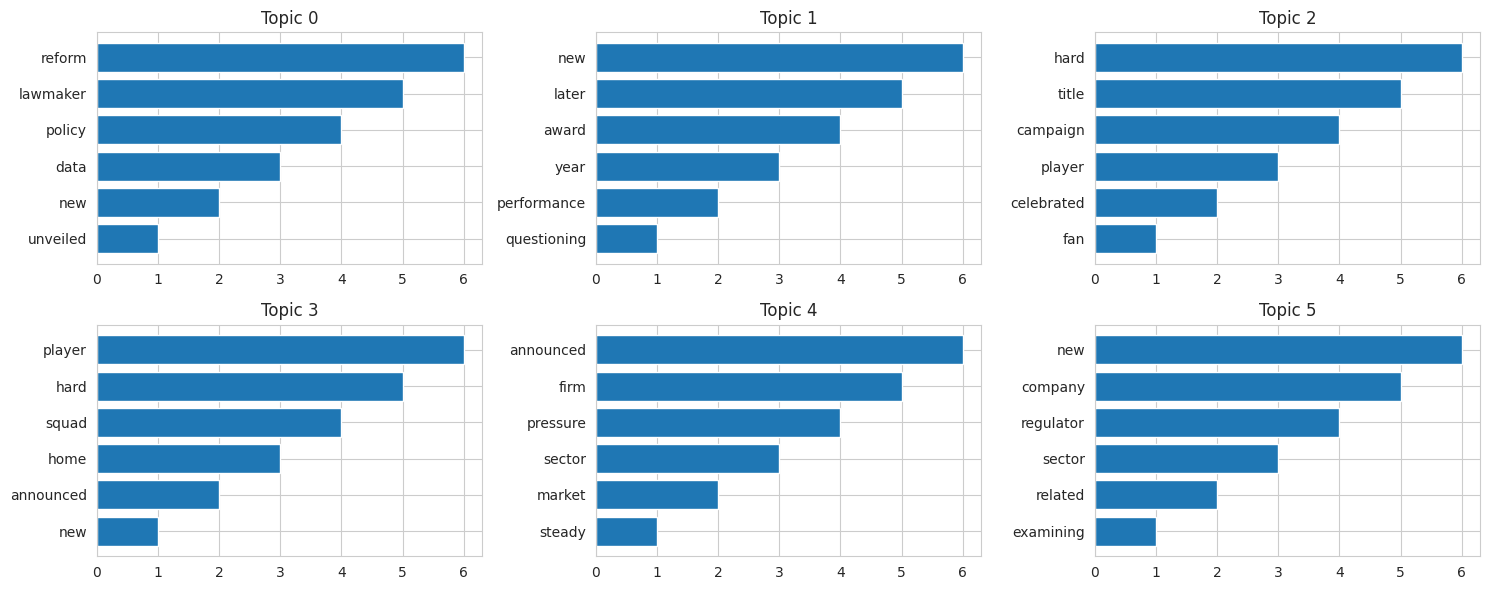

In [5]:
from src.utils.visualization import plot_topic_words

fig = plot_topic_words(lda_model.get_all_topics(n_words=6))
plt.show()

## Content clustering by dominant topic

In [6]:
df['dominant_topic'] = lda_model.dominant_topic_per_doc()
clusters = lda_model.cluster_by_topic()
for topic_id, doc_indices in clusters.items():
    print(f"Topic {topic_id}: {len(doc_indices)} articles | top words: {', '.join(lda_model.get_topic_words(topic_id, 6))}")

Topic 0: 40 articles | top words: reform, lawmaker, policy, data, new, unveiled
Topic 1: 40 articles | top words: new, later, award, year, performance, questioning
Topic 2: 0 articles | top words: hard, title, campaign, player, celebrated, fan
Topic 3: 40 articles | top words: player, hard, squad, home, announced, new
Topic 4: 40 articles | top words: announced, firm, pressure, sector, market, steady
Topic 5: 40 articles | top words: new, company, regulator, sector, related, examining


## How well do discovered topics align with true categories?

In [7]:
alignment = pd.crosstab(df['category'], df['dominant_topic'])
alignment

dominant_topic,0,1,3,4,5
category,,,,,
business,0,0,0,40,0
entertainment,0,40,0,0,0
politics,40,0,0,0,0
sport,0,0,40,0,0
tech,0,0,0,0,40


## Key Takeaways
- LDA and NMF surface coherent topic clusters that broadly align with the known BBC categories, validating the topic model against ground truth.
- `TopicModeler.topic_evolution()` (see docstring) supports tracking topic prevalence over time once a real publication-date column is available in the full Kaggle dataset.
- Topic assignments are stored per-article and reused by the Django dashboard's 'Discovered Topics' panel.